<a href="https://colab.research.google.com/github/SandAhmed/Team-Megaforce-Ai-project/blob/main/preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier

In [7]:
df = pd.read_csv('/content/train_data.csv')

In [8]:
df.tail()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
299,LP001367,Male,Yes,1,Graduate,No,3052,1030.0,100.0,360.0,1.0,Urban,Y
300,LP001606,Male,Yes,0,Graduate,No,3497,1964.0,116.0,360.0,1.0,Rural,Y
301,LP002366,Male,Yes,0,Graduate,No,2666,4300.0,121.0,360.0,1.0,Rural,Y
302,LP002777,Male,Yes,0,Graduate,No,2785,2016.0,110.0,360.0,1.0,Rural,Y
303,LP001579,Male,No,0,Graduate,No,2237,0.0,63.0,480.0,0.0,Semiurban,N


In [68]:
print(df.dtypes)

Loan_ID               object
Married                int64
Dependents            object
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
TotalIncome          float64
dtype: object


In [72]:
le = LabelEncoder()
categ_cols = [ 'Loan_ID','Married', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']

for col in categ_cols:
  df[col] = le.fit_transform(df[col])

print(df.dtypes)

Loan_ID                int64
Married                int64
Dependents            object
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
TotalIncome          float64
dtype: object


In [9]:
#null values percentage
df.isna().sum()/len(df)*100

,0
Loan_ID,0.000000
Gender,0.986842
Married,0.000000
Dependents,2.302632
Education,0.000000
Self_Employed,5.592105
ApplicantIncome,0.000000
CoapplicantIncome,0.000000
LoanAmount,0.000000
Loan_Amount_Term,2.960526


In [79]:
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
#df['Gender'].fillna(df['Gender'].mode()[0], inplace=True, errors = 'ignore')
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)

/tmp/ipykernel_1846/1890339797.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
/tmp/ipykernel_1846/1890339797.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inp

In [76]:
df['Loan_Amount_Term']=df["Loan_Amount_Term"].fillna(df['Loan_Amount_Term'].median())
df['Credit_History']=df["Credit_History"].fillna(df['Credit_History'].median())
df['Credit_History']=df["Credit_History"].fillna(df['Credit_History'].median())

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304 entries, 0 to 303
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            304 non-null    object 
 1   Gender             301 non-null    object 
 2   Married            304 non-null    object 
 3   Dependents         304 non-null    object 
 4   Education          304 non-null    object 
 5   Self_Employed      287 non-null    object 
 6   ApplicantIncome    304 non-null    int64  
 7   CoapplicantIncome  304 non-null    float64
 8   LoanAmount         304 non-null    float64
 9   Loan_Amount_Term   295 non-null    float64
 10  Credit_History     281 non-null    float64
 11  Property_Area      304 non-null    object 
 12  Loan_Status        304 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 31.0+ KB


In [12]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,304.000000,304.000000,304.000000,295.000000,281.000000
mean,3583.828947,1220.645132,105.282895,342.101695,0.822064
std,1366.102888,1732.098606,28.696412,67.192306,0.383141
min,210.000000,0.000000,17.000000,12.000000,0.000000
25%,2651.000000,0.000000,90.000000,360.000000,1.000000
50%,3365.500000,953.000000,110.500000,360.000000,1.000000
75%,4284.250000,2045.000000,128.000000,360.000000,1.000000
max,9703.000000,20000.000000,150.000000,480.000000,1.000000


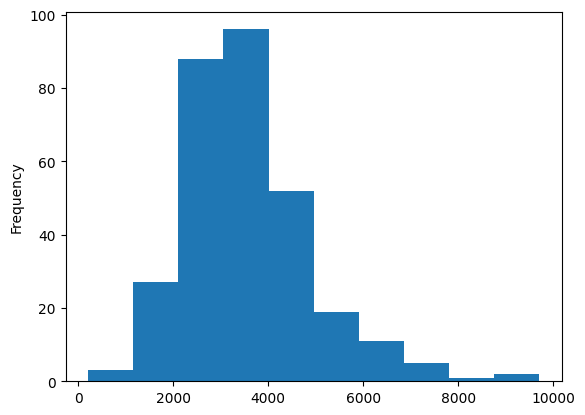

In [13]:
plt.hist(df['ApplicantIncome'])
plt.ylabel("Frequency")
plt.show()

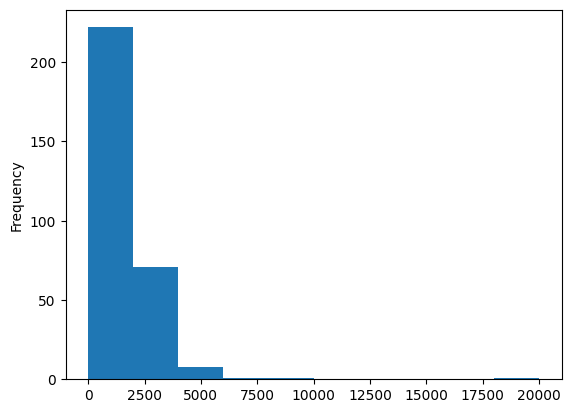

In [14]:
plt.hist(df['CoapplicantIncome'])
plt.ylabel("Frequency")
plt.show()

In [15]:
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

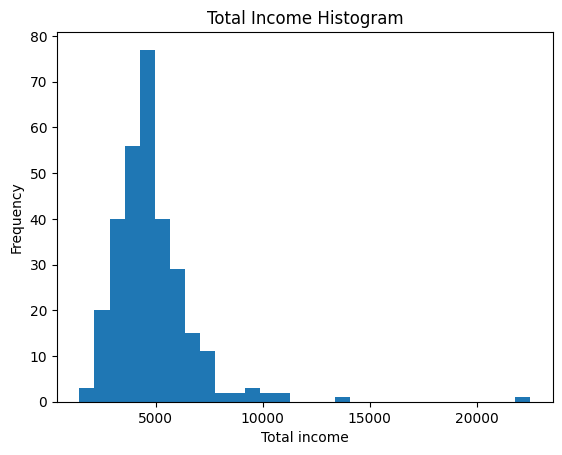

In [16]:
plt.hist(df['TotalIncome'], bins=30)
plt.title("Total Income Histogram")
plt.xlabel("Total income")
plt.ylabel("Frequency")
plt.show()

In [67]:
print(df.dtypes)

Loan_ID               object
Married                int64
Dependents            object
Education              int64
Self_Employed          int64
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area          int64
Loan_Status            int64
TotalIncome          float64
dtype: object


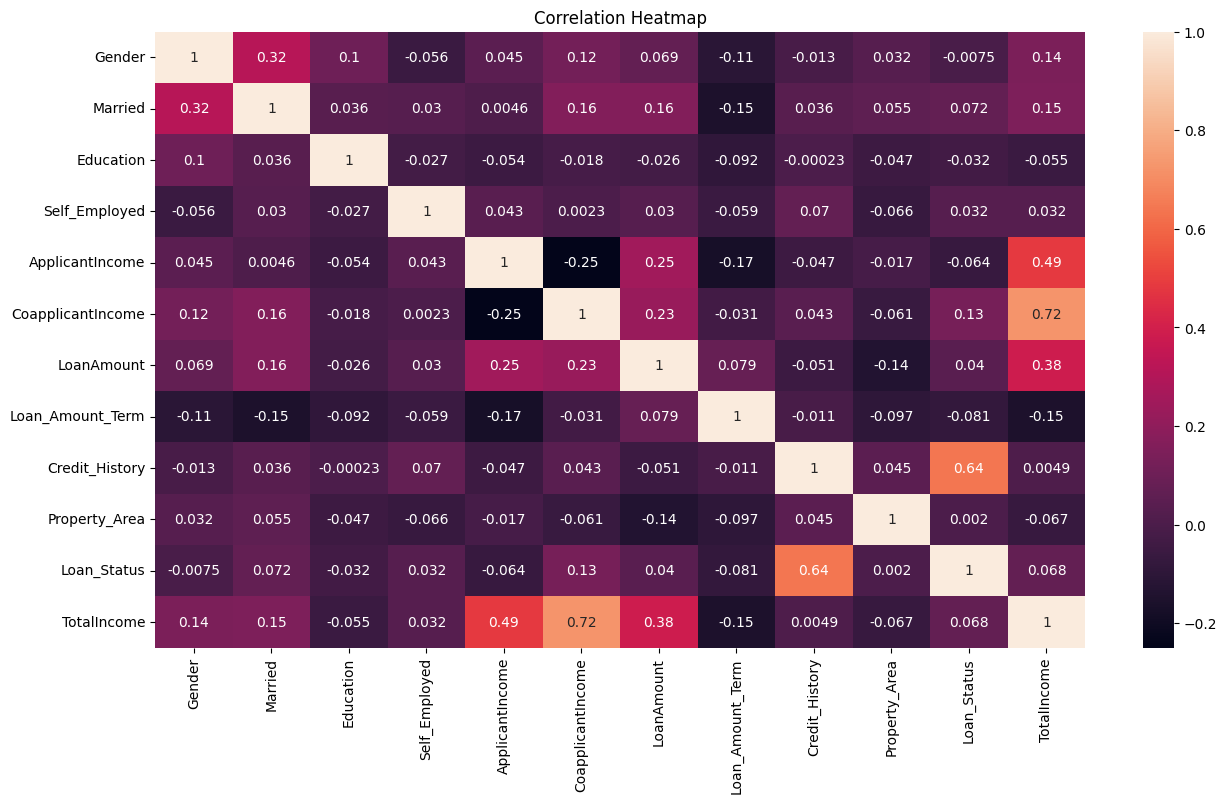

In [38]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True)
plt.title('Correlation Heatmap')
plt.show()

In [45]:
#dropped because the correlation coofecient between it and the loan status is low
df = df.drop('Gender',errors='ignore')

In [44]:
df.tail()

,Loan_ID,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
299,LP001367,1,1,0,0,3052,1030.0,100.0,360.0,1.0,2,1,4082.0
300,LP001606,1,0,0,0,3497,1964.0,116.0,360.0,1.0,0,1,5461.0
301,LP002366,1,0,0,0,2666,4300.0,121.0,360.0,1.0,0,1,6966.0
302,LP002777,1,0,0,0,2785,2016.0,110.0,360.0,1.0,0,1,4801.0
303,LP001579,0,0,0,0,2237,0.0,63.0,480.0,0.0,1,0,2237.0


In [49]:
features = ['Married', 'Dependents', 'Education', 'Self_Employed',
            'Credit_History', 'Property_Area', 'Loan_Amount_Term',]

In [65]:
x = df[features]
y = df['Loan_Status']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [83]:
df['Dependents'] = df['Dependents'].replace('3+', '3')
df['Dependents'] = df['Dependents'].astype(int)

In [84]:
model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3)
model.fit(x_train, y_train)

ValueError: could not convert string to float: '3+'